# Indian Pines MAE Visualization

This notebook loads the latest checkpoint from `modelarchive/indian_pines_mae`, rebuilds the trained `SpectralSharedEncoder`, and visualizes:

- encoder embeddings for labeled Indian Pines pixels
- original vs reconstructed spectra
- full-scene reconstruction error heatmap

It works with the `trainer.py` checkpoints created in this repo.

In [4]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import minmax_scale

ROOT = Path.cwd()
if not (ROOT / 'engine').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from engine.model import SpectralSharedEncoder

CHECKPOINT_DIR = ROOT / 'modelarchive' / 'indian_pines_mae'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'embed256_enc8_dec8_heads8_mask75_epoch100.pt'
DATA_PATH = Path('/home/dk6012/Desktop/darpa_ai/data/IndianPine.mat')
WAVELENGTHS_PATH = None  # set to a .csv/.txt/.npy file if you have real wavelengths

EMBED_SAMPLE_SIZE = 3000
TSNE_SAMPLE_SIZE = 1500
RECON_SAMPLE_SIZE = 6
BATCH_SIZE = 1024
RUN_TSNE = True
SEED = 0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

In [5]:
def latest_checkpoint(ckpt_dir: Path) -> Path:
    pattern = re.compile(r'(?:^|_)epoch_?(\d+)\.pt$')
    candidates = [path for path in ckpt_dir.glob('*.pt') if pattern.search(path.name)]
    if not candidates:
        raise FileNotFoundError(f'No checkpoints found in {ckpt_dir}')
    return max(candidates, key=lambda path: int(pattern.search(path.name).group(1)))


def clean_state_dict(state_dict):
    cleaned = {}
    for key, value in state_dict.items():
        if key.startswith('module.'):
            key = key[7:]
        cleaned[key] = value
    return cleaned


def load_wavelengths(num_bands: int, wavelengths_path=None, wave_min=400.0, wave_max=2500.0):
    if wavelengths_path is None:
        return np.linspace(wave_min, wave_max, num_bands, dtype=np.float32), False
    wavelengths_path = Path(wavelengths_path)
    if wavelengths_path.suffix.lower() == '.npy':
        wavelengths = np.load(wavelengths_path).astype(np.float32)
    elif wavelengths_path.suffix.lower() == '.csv':
        wavelengths = pd.read_csv(wavelengths_path).iloc[:, -1].to_numpy(dtype=np.float32)
    else:
        wavelengths = np.loadtxt(wavelengths_path, dtype=np.float32)
    wavelengths = np.asarray(wavelengths, dtype=np.float32).reshape(-1)
    if len(wavelengths) != num_bands:
        raise ValueError(f'Expected {num_bands} wavelengths, got {len(wavelengths)}')
    return wavelengths, True


def load_indian_pines(data_path: Path, wavelengths_path=None):
    mat = loadmat(data_path)
    cube = mat['input'].astype(np.float32)
    tr = mat['TR'].astype(np.int64)
    te = mat['TE'].astype(np.int64)

    h, w, c = cube.shape
    flat = cube.reshape(-1, c)
    flat = minmax_scale(flat).astype(np.float32)
    cube_norm = flat.reshape(h, w, c)

    label_map = tr.copy()
    label_map[te > 0] = te[te > 0]
    flat_labels = label_map.reshape(-1)
    labeled_indices = np.flatnonzero(flat_labels > 0)

    wavelengths, has_real_waves = load_wavelengths(c, wavelengths_path)
    return {
        'cube': cube_norm,
        'shape': cube_norm.shape,
        'flat_spectra': flat,
        'flat_labels': flat_labels,
        'labeled_indices': labeled_indices,
        'wavelengths': wavelengths,
        'has_real_waves': has_real_waves,
        'train_mask': tr,
        'test_mask': te,
        'label_map': label_map,
    }


def load_model(checkpoint_path: Path, device):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    args = checkpoint.get('args', {})
    model = SpectralSharedEncoder(
        embedding_dim=args.get('embedding_dim', 256),
        encoder_depth=args.get('encoder_depth', 8),
        decoder_depth=args.get('decoder_depth', 4),
        num_heads=args.get('num_heads', 8),
    )
    model.load_state_dict(clean_state_dict(checkpoint['model']))
    model.to(device)
    model.eval()
    return model, checkpoint, args


def encode_spectra(model, spectra, wavelengths, batch_size=1024, device='cpu'):
    wave = torch.from_numpy(wavelengths).float()
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(spectra), batch_size):
            batch = torch.from_numpy(spectra[start:start + batch_size, None, :]).float().to(device)
            batch_wave = wave.unsqueeze(0).expand(batch.shape[0], -1).to(device)
            z, _, _, _, _, _ = model.encoder_forward(batch, batch_wave, 0.0)
            embeddings.append(z.squeeze(1).cpu().numpy())
    return np.concatenate(embeddings, axis=0)


def reconstruct_spectra(model, spectra, wavelengths, mask_ratio=0.0, batch_size=1024, device='cpu'):
    wave = torch.from_numpy(wavelengths).float()
    recons = []
    with torch.no_grad():
        for start in range(0, len(spectra), batch_size):
            batch = torch.from_numpy(spectra[start:start + batch_size, None, :]).float().to(device)
            batch_wave = wave.unsqueeze(0).expand(batch.shape[0], -1).to(device)
            _, recon = model(batch, batch_wave, mask_ratio)
            recons.append(recon.squeeze(1).cpu().numpy())
    return np.concatenate(recons, axis=0)


In [6]:
rng = np.random.default_rng(SEED)
ckpt_path = Path(CHECKPOINT_PATH) if CHECKPOINT_PATH is not None else latest_checkpoint(CHECKPOINT_DIR)
model, checkpoint, train_args = load_model(ckpt_path, DEVICE)
data = load_indian_pines(DATA_PATH, WAVELENGTHS_PATH)
train_args = pd.Series(train_args).sort_index()

print(f'Checkpoint: {ckpt_path}')
print(f"Epoch saved: {checkpoint.get('epoch')} | Step saved: {checkpoint.get('step')}")
print(f"Device: {DEVICE}")
print(f"Data shape: {data['shape']}")
print(f"Labeled pixels: {len(data['labeled_indices'])}")
print(f"Using real wavelengths: {data['has_real_waves']}")
display(train_args)


model initialized
Checkpoint: /home/dk6012/Desktop/darpa_ai/hypersl/modelarchive/indian_pines_mae/embed256_enc8_dec8_heads8_mask75_epoch100.pt
Epoch saved: 99 | Step saved: 4200
Device: cuda
Data shape: (145, 145, 200)
Labeled pixels: 10366
Using real wavelengths: False


batch_size                                                           512
data_path              /home/dk6012/Desktop/darpa_ai/data/splits/Indi...
decoder_depth                                                          8
disable_amp                                                        False
disable_tensorboard                                                 True
embedding_dim                                                        256
encoder_depth                                                          8
epochs                                                               100
grad_clip                                                            5.0
lr                                                                0.0005
mask_ratio                                                          0.75
max_steps_per_epoch                                                 None
num_heads                                                              8
num_workers                                        

In [7]:
embed_pool = data['labeled_indices']
embed_take = min(EMBED_SAMPLE_SIZE, len(embed_pool))
embed_idx = rng.choice(embed_pool, size=embed_take, replace=False)
embed_spectra = data['flat_spectra'][embed_idx]
embed_labels = data['flat_labels'][embed_idx] - 1

embeddings = encode_spectra(model, embed_spectra, data['wavelengths'], batch_size=BATCH_SIZE, device=DEVICE)
embeddings.shape

(3000, 256)

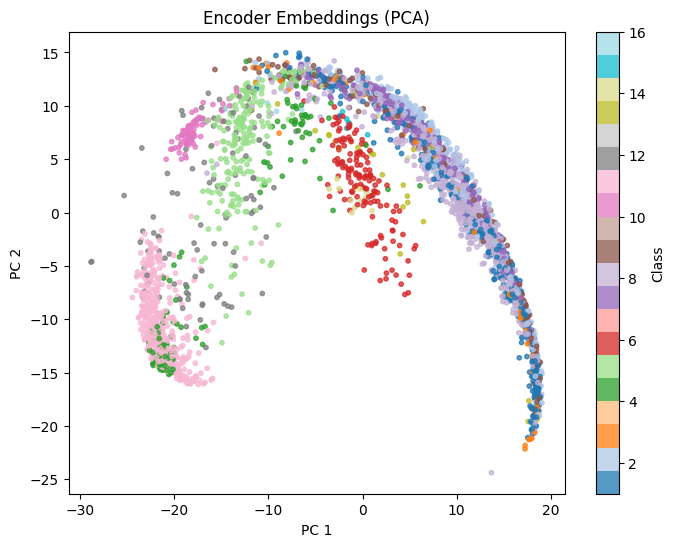

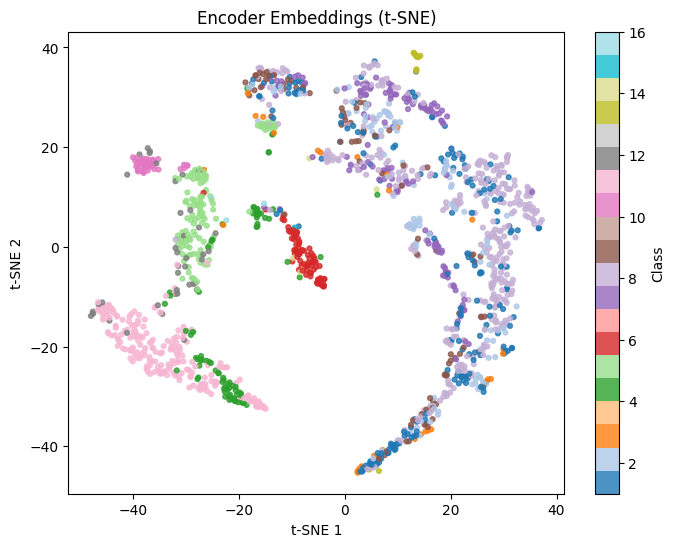

In [8]:
pca = PCA(n_components=2, random_state=SEED)
emb_pca = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(emb_pca[:, 0], emb_pca[:, 1], c=embed_labels + 1, s=10, cmap='tab20', alpha=0.75)
ax.set_title('Encoder Embeddings (PCA)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.colorbar(scatter, ax=ax, label='Class')
plt.show()

if RUN_TSNE and len(embeddings) >= 2:
    tsne_take = min(TSNE_SAMPLE_SIZE, len(embeddings))
    tsne_sel = rng.choice(np.arange(len(embeddings)), size=tsne_take, replace=False)
    perplexity = max(2, min(30, tsne_take - 1))
    emb_tsne = TSNE(
        n_components=2,
        init='pca',
        learning_rate='auto',
        perplexity=perplexity,
        random_state=SEED,
    ).fit_transform(embeddings[tsne_sel])

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=embed_labels[tsne_sel] + 1, s=12, cmap='tab20', alpha=0.8)
    ax.set_title('Encoder Embeddings (t-SNE)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    plt.colorbar(scatter, ax=ax, label='Class')
    plt.show()

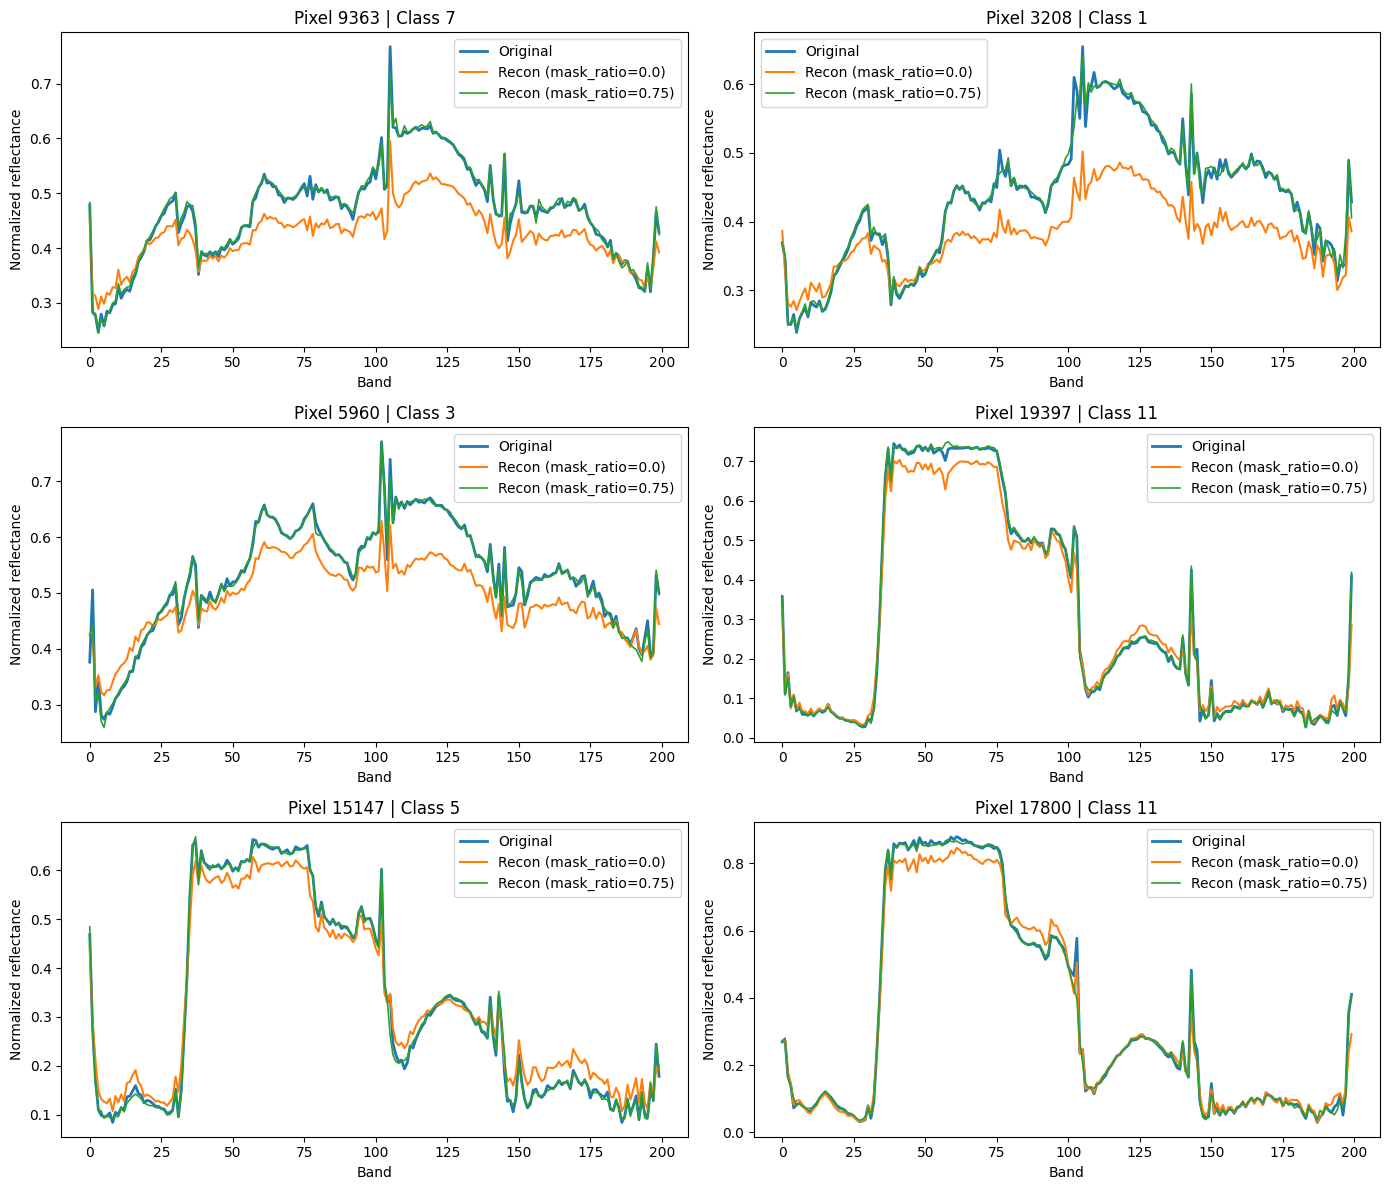

In [9]:
mask_ratio = float(train_args.get('mask_ratio', 0.75))
recon_take = min(RECON_SAMPLE_SIZE, len(data['labeled_indices']))
recon_idx = rng.choice(data['labeled_indices'], size=recon_take, replace=False)
orig = data['flat_spectra'][recon_idx]
labels = data['flat_labels'][recon_idx]

recon_nomask = reconstruct_spectra(model, orig, data['wavelengths'], mask_ratio=0.0, batch_size=recon_take, device=DEVICE)
recon_masked = reconstruct_spectra(model, orig, data['wavelengths'], mask_ratio=mask_ratio, batch_size=recon_take, device=DEVICE)

ncols = 2
nrows = int(np.ceil(recon_take / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), squeeze=False)
axes = axes.ravel()

for ax, pixel_idx, label, original, no_mask, masked in zip(axes, recon_idx, labels, orig, recon_nomask, recon_masked):
    ax.plot(original, label='Original', linewidth=2)
    ax.plot(no_mask, label='Recon (mask_ratio=0.0)', linewidth=1.5)
    ax.plot(masked, label=f'Recon (mask_ratio={mask_ratio:.2f})', linewidth=1.2)
    ax.set_title(f'Pixel {pixel_idx} | Class {label}')
    ax.set_xlabel('Band')
    ax.set_ylabel('Normalized reflectance')
    ax.legend(loc='best')

for ax in axes[recon_take:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

(145, 145)
Mean MSE across all pixels: 0.030852765


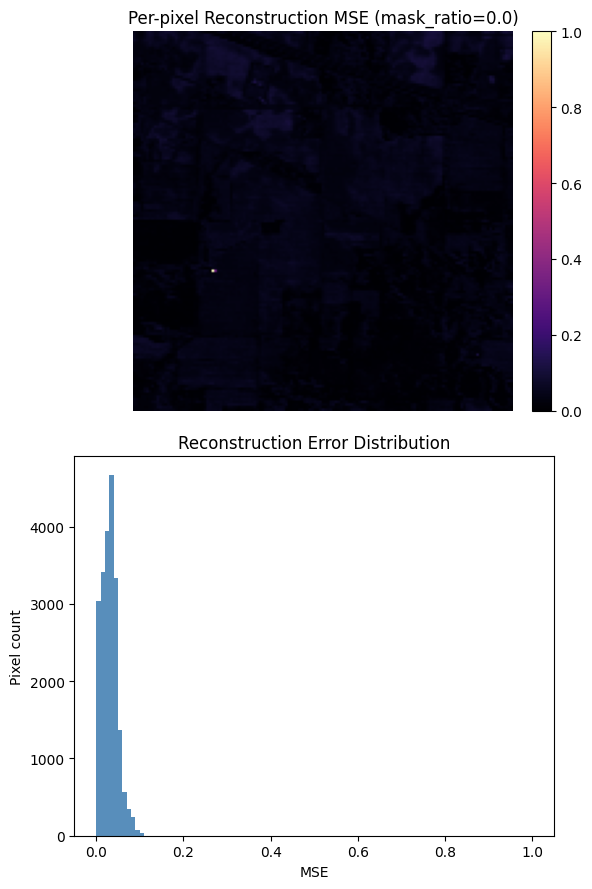

: 

In [ ]:
all_recon = reconstruct_spectra(
    model,
    data['flat_spectra'],
    data['wavelengths'],
    mask_ratio=0.0,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)

mse_map = ((all_recon - data['flat_spectra']) ** 2).mean(axis=1).reshape(data['shape'][:2])
print(mse_map.shape)
exit()
# normalize mse_map for better visualization
mse_map = minmax_scale(mse_map.reshape(-1)).reshape(mse_map.shape)

print("Mean MSE across all pixels:", mse_map.mean())
fig, axes = plt.subplots(2, 1, figsize=(6, 9))
im = axes[0].imshow(mse_map, cmap='magma')
axes[0].set_title('Per-pixel Reconstruction MSE (mask_ratio=0.0)')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].hist(mse_map.reshape(-1), bins=100, color='steelblue', alpha=0.9)
axes[1].set_title('Reconstruction Error Distribution')
axes[1].set_xlabel('MSE')
axes[1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()
